In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ['MUJOCO_GL'] = 'egl'

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
import sys

sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')
#from tdmpc2 import TDMPC2
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied



In [3]:
from common.latent_projector import LatentProjector
from common.nonlinear_latent_projector import NonlinearLatentProjector
from projected_tdmpc2 import ProjectedTDMPC2


In [4]:
from analysis.utils import load_sweep_metadata, load_data

CKPT_TO_USE = 500_000
df_metadata = load_sweep_metadata(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep",
    json_file_name="episode_metadata.json",
)

df = load_data(
    df_metadata,
    episode_file_name="episode_data.pkl",
)

df['ckpt_int'] = df['checkpoint'].apply(
    lambda x: int(x.split('/')[-1].split('.')[0]))
df['angle_degrees'] = df['initial_state'].apply(lambda x: np.degrees(x[1]))
df = df[~df['angle_degrees'].isin([0.0, 360.0])]

df = df[df['ckpt_int'] == CKPT_TO_USE]
z = np.concatenate(df['latent_states'].tolist())
obs = np.concatenate(df['observations'].tolist())
actions = np.concatenate(df['actions'].tolist())

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep: 100%|██████████| 108/108 [00:00<00:00, 1096.24it/s]


Found 108 configurations
Found 108 configurations


100%|██████████| 108/108 [00:01<00:00, 100.42it/s]


In [110]:
# Add k-step future state (observation at t+k) to current observation to build time-lagged (future) embeddings
# For each t and each k in k_futures, form [obs_t, obs_{t+k}], concatenate all such features along the last dim
k_futures = [5]  # can include multiple steps, e.g. [1, 5, 10]

future_features = []
for k_future in k_futures:
    if k_future >= len(obs):
        raise ValueError(
            f"k_future={k_future} is too large for the length of obs.")
    # Create features: [obs_t, obs_{t+k}]
    fut = np.concatenate([obs[:-k_future], obs[k_future:]], axis=-1)
    future_features.append(fut)

# Stack features along the last dimension (feature axis)
# First, all feature arrays must have the same leading dimension
obs_future = np.concatenate(future_features, axis=-1)

# Now obs_future is a single array of shape [N - max(k_futures), features * len(k_futures)]

In [112]:
z_future = z[:-max(k_futures)]

In [105]:
obs_future.shape

(5990, 10)

In [114]:
# # Find directions maximally correlated with state
#projector = LatentProjector.fit(z, k=10, method='cca', states=obs, ridge=1e-4)

# Hybrid CCA: 5 state-predictive directions + 27 variance-preserving directions
projector = LatentProjector.fit(z_future,
                                k=15,
                                method='cca',
                                states=obs_future,
                                k_supervised=5,
                                ridge=1e-4)

#projector = LatentProjector.fit(z, k=10, method='rrr', states=obs, ridge=1e-4)

LatentProjector.fit (cca): k=10, canonical_corr=[0.9997832179069519, 0.9995371103286743, 0.9990490078926086, 0.9985966682434082, 0.9973692297935486, 0.9486558437347412, 0.9337746500968933, 0.5938235521316528, 0.5339854955673218, 0.014505214057862759]


In [115]:
var_explained = projector.explained_variance_ratio(z)
print(var_explained)

0.2936131954193115


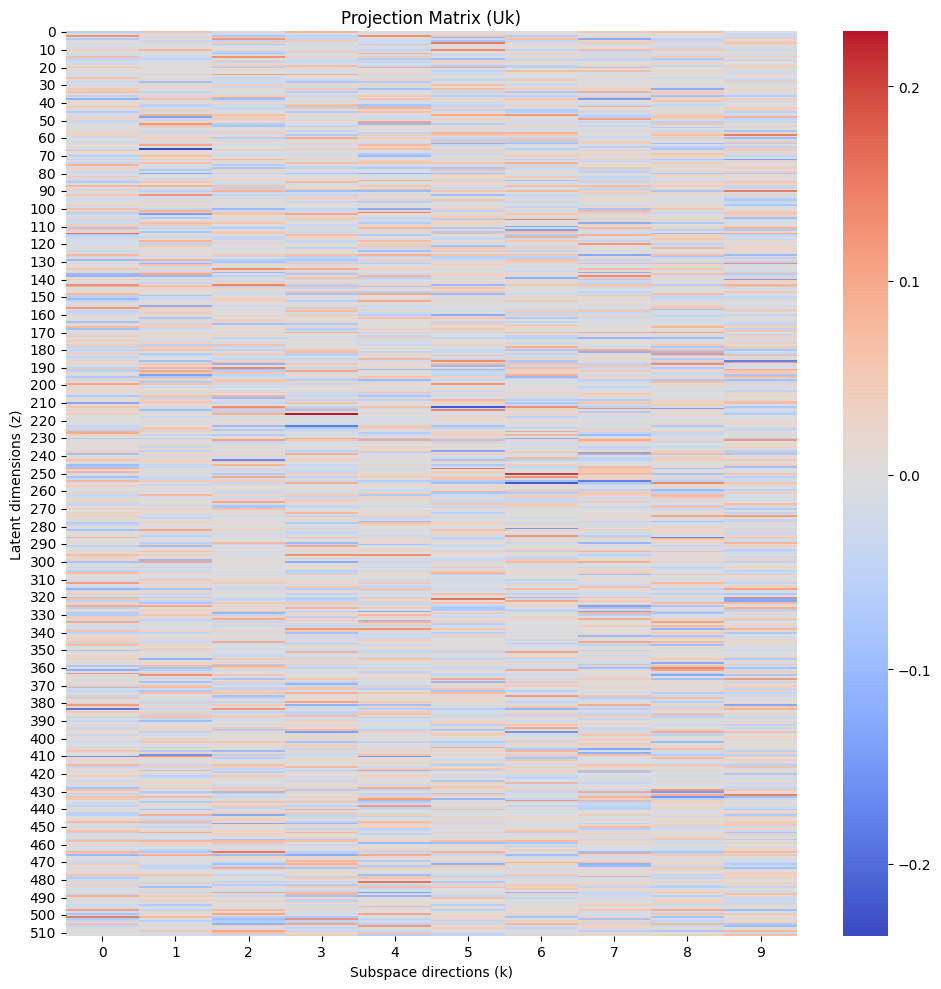

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

# Show Uk nicely: heatmap with labeled axes
plt.figure(figsize=(10, 10))
sns.heatmap(
    projector.Uk.cpu().numpy(),
    cmap="coolwarm",
    center=0,
)
plt.xlabel("Subspace directions (k)")
plt.ylabel("Latent dimensions (z)")
plt.title("Projection Matrix (Uk)")
plt.tight_layout()
plt.show()

In [ ]:
Uk = projector.Uk
U_state = Uk[:, :5]
U_pca = Uk[:, 5:]

z_state = projector.project(torch.from_numpy(z).to('cuda'),
                            U=U_state).detach().cpu().numpy()
z_pca = projector.project(torch.from_numpy(z).to('cuda'),
                          U=U_pca).detach().cpu().numpy()


In [ ]:
pos_square = obs[:, 0]**2
vel_square = obs[:, 1]**2
pos_vel = obs[:, 0] * obs[:, 1]
#acc_norm = np.linalg.norm(obs[:, 2:], axis=1)

obs_extra = np.concatenate(
    [pos_square[:, None], vel_square[:, None], pos_vel[:, None]], axis=1)

In [ ]:
k = 20
obs_tpk = obs[k:]
actions_tpk = actions[k:]

c_state_tpk = c_state[:-k if k > 0 else None]
c_pca_tpk = c_pca[:-k if k > 0 else None]


In [ ]:
obs_tpk.shape

(8980, 5)

In [ ]:
c_pca_tpk.shape

(8980, 512)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

y = obs
X_state = z_state
X_pca = z_pca

# obs_tpk
# X_state = np.concatenate([c_state_tpk, actions_tpk], axis=1)
# X_pca = np.concatenate([c_state_tpk, c_pca_tpk, actions_tpk], axis=1)

# Train/test split: hold out episodes (each episode is 500 samples)
num_per_episode = 500
num_episodes = X_state.shape[0] // num_per_episode

# We'll use 80% of episodes for train, 20% for test
rng = np.random.default_rng(44)
episodes = np.arange(num_episodes)
rng.shuffle(episodes)
split_idx = int(0.8 * num_episodes)
train_episodes = episodes[:split_idx]
test_episodes = episodes[split_idx:]

# Build indices for train/test based on episodes
train_idx = np.concatenate([
    np.arange(e * num_per_episode, (e + 1) * num_per_episode)
    for e in train_episodes
])
test_idx = np.concatenate([
    np.arange(e * num_per_episode, (e + 1) * num_per_episode)
    for e in test_episodes
])

# Linear regression and R2 between X_state and observations (episode held-out split)
reg_state = LinearRegression()
reg_state.fit(X_state[train_idx], y[train_idx])
obs_pred_state = reg_state.predict(X_state[test_idx])
r2_state = r2_score(y[test_idx], obs_pred_state)
print(f"R^2 (state directions -> obs, held-out episodes): {r2_state:.4f}")

# Linear regression and R2 between X_pca and observations (episode held-out split)
reg_pca = LinearRegression()
reg_pca.fit(X_pca[train_idx], y[train_idx])
obs_pred_pca = reg_pca.predict(X_pca[test_idx])
r2_pca = r2_score(y[test_idx], obs_pred_pca)
print(f"R^2 (PCA directions -> obs, held-out episodes): {r2_pca:.4f}")

R^2 (state directions -> obs, held-out episodes): 0.9998
R^2 (PCA directions -> obs, held-out episodes): 0.7109


## Decoding analysis for 

In [7]:
from analysis.utils_decoding import evaluate_lags_leave_k_out
from analysis.utils import chunk_data

In [ ]:
results_state = {}
results_pca = {}
for dim in range(5):
    obs_dim = obs[:, dim]
    results_state_ = evaluate_lags_leave_k_out(chunk_data(z_state),
                                               chunk_data(obs_dim),
                                               np.arange(-40, 41, 10),
                                               k_holdout=1,
                                               model='linear_regression',
                                               add_bootstrap_ci=True)

    results_pca_ = evaluate_lags_leave_k_out(chunk_data(z_pca),
                                             chunk_data(obs_dim),
                                             np.arange(-40, 41, 10),
                                             k_holdout=1,
                                             model='linear_regression',
                                             add_bootstrap_ci=True)

    results_state[dim] = results_state_
    results_pca[dim] = results_pca_

100%|██████████| 12/12 [00:10<00:00,  1.19it/s]


{'train_r2_mean': {-40: 0.46335771183172864, -30: 0.725885679324468, -20: 0.9052636375029882, -10: 0.9858507563670477, 0: 0.999517356355985, 10: 0.9797948797543844, 20: 0.840050627787908, 30: 0.610555296142896, 40: 0.381484034160773}, 'train_r2_std': {-40: 0.030708961830040692, -30: 0.020771109221207368, -20: 0.00708109181491223, -10: 0.0011283084384130736, 0: 3.2032032971864355e-05, 10: 0.0014266569319220219, 20: 0.010329419709564117, 30: 0.019672755614911438, 40: 0.023566378966144393}, 'test_r2_mean': {-40: 0.02911452700694402, -30: 0.43184547622998554, -20: 0.8039167920748392, -10: 0.9707893331845602, 0: 0.9989895721276602, 10: 0.9626974761486053, 20: 0.6911248564720154, 30: 0.23664906869331995, 40: -0.05945352713267008}, 'test_r2_std': {-40: 0.6755213439336262, -30: 0.596332768789519, -20: 0.188128866300915, -10: 0.025129473832043153, 0: 0.001118355745303845, 10: 0.02773851384650361, 20: 0.22731555893691666, 30: 0.5339561343196195, 40: 0.6194260649380946}, 'train_r2_by_lag': {-40: 

100%|██████████| 12/12 [00:10<00:00,  1.20it/s]


{'train_r2_mean': {-40: 0.5843169043461481, -30: 0.6934522837400436, -20: 0.7371704230705897, -10: 0.6698062767585119, 0: 0.541565145055453, 10: 0.527198888361454, 20: 0.5303080330292383, 30: 0.5064354365070661, 40: 0.4600430528322856}, 'train_r2_std': {-40: 0.03801545167162038, -30: 0.03375585313101127, -20: 0.021096565114063517, -10: 0.02630594159864356, 0: 0.030756640130923517, 10: 0.04163062458108598, 20: 0.04951173291425703, 30: 0.05827929208583863, 40: 0.061045464187198334}, 'test_r2_mean': {-40: -0.16565907498200735, -30: 0.08432592079043388, -20: 0.36466412742932636, -10: 0.2634739875793457, 0: -0.0750098234663407, 10: -0.18914096057415009, 20: -0.22738452007373175, 30: -0.47359559933344525, 40: -0.6332429597775141}, 'test_r2_std': {-40: 0.8936777875161065, -30: 0.816059367065685, -20: 0.42188742181736055, -10: 0.6477750694264699, 0: 0.9376299490921993, 10: 0.9197644432139382, 20: 1.1660402334951137, 30: 1.6222833769581733, 40: 1.8462102438283376}, 'train_r2_by_lag': {-40: [0.6

100%|██████████| 12/12 [00:10<00:00,  1.20it/s]


...

{'train_r2_mean': {-40: 0.3571830938259761, -30: 0.4858906964461009, -20: 0.7003117154041926, -10: 0.6291004568338394, 0: 0.7060741633176804, 10: 0.6996314177910486, 20: 0.5885972529649734, 30: 0.5343653211990992, 40: 0.551004447042942}, 'train_r2_std': {-40: 0.03894282699294026, -30: 0.03522262798302728, -20: 0.030404286505697754, -10: 0.030942346230693012, 0: 0.021300547483714433, 10: 0.02268951221837514, 20: 0.03244593989519492, 30: 0.04171599319715662, 40: 0.04987832667297914}, 'test_r2_mean': {-40: -0.5040771116813024, -30: -0.190510972092549, -20: 0.23828758796056113, -10: 0.16728766014178595, 0: 0.4180605287353198, 10: 0.39314563820759457, 20: 0.22919425865014395, 30: -0.018174360195795696, 40: -0.23840938632686934}, 'test_r2_std': {-40: 1.0973781589123592, -30: 0.9532801975365102, -20: 0.7695670250799036, -10: 0.6881777986280578, 0: 0.4995289487263555, 10: 0.559054668859094, 20: 0.5662880623694682, 30: 0.8861281402624854, 40: 1.6482397843178895}, 'train_r2_by_lag': {-40: [0.392

100%|██████████| 12/12 [00:10<00:00,  1.20it/s]


{'train_r2_mean': {-40: 0.3083114301164945, -30: 0.5082298666238785, -20: 0.7555364221334457, -10: 0.9332667936881384, 0: 0.9997552186250687, 10: 0.9254505385955175, 20: 0.755619153380394, 30: 0.6064628263314565, 40: 0.5825793296098709}, 'train_r2_std': {-40: 0.02802510643679032, -30: 0.019107034941390454, -20: 0.011098394435505716, -10: 0.0031485692426480383, 0: 1.2079937430901124e-05, 10: 0.004805390273023355, 20: 0.01042392620185048, 30: 0.018998741501765472, 40: 0.040879249070895636}, 'test_r2_mean': {-40: 0.17556866258382797, -30: 0.4068860299885273, -20: 0.7005912537376086, -10: 0.9110256979862849, 0: 0.9997212439775467, 10: 0.8981993248065313, 20: 0.6691264162460963, 30: 0.32145826518535614, 40: -0.29570670425891876}, 'test_r2_std': {-40: 0.40626532455608, -30: 0.2930998086995861, -20: 0.14613835998084967, -10: 0.05089704130121519, 0: 0.00013138634254510273, 10: 0.09128818656352136, 20: 0.28052680017607223, 30: 0.7370761193019528, 40: 1.5094492206455026}, 'train_r2_by_lag': {-40

100%|██████████| 12/12 [00:10<00:00,  1.19it/s]


{'train_r2_mean': {-40: 0.5686450948317846, -30: 0.7530234605073929, -20: 0.8738308747609457, -10: 0.8892469505469004, 0: 0.8013723840316137, 10: 0.8276626219352087, 20: 0.7462792346874872, 30: 0.7341974377632141, 40: 0.7812868555386862}, 'train_r2_std': {-40: 0.011167796405606693, -30: 0.011755013284374442, -20: 0.008584488778366593, -10: 0.009544009323182383, 0: 0.015637080201743533, 10: 0.01651484585953678, 20: 0.018645327300072217, 30: 0.02671511765753109, 40: 0.030744928480328067}, 'test_r2_mean': {-40: 0.12668791397785148, -30: 0.5951846241950989, -20: 0.7731396754582723, -10: 0.797342744966348, 0: 0.682548971225818, 10: 0.695285419623057, 20: 0.5972769012053808, 30: 0.5768285940090815, 40: 0.40256938834985095}, 'test_r2_std': {-40: 0.8085019530275009, -30: 0.2919250229585776, -20: 0.1740182543651927, -10: 0.1726591414619893, 0: 0.25887341125633456, 10: 0.29656176781728133, 20: 0.3062448335815735, 30: 0.33964763439060774, 40: 0.6608997846671776}, 'train_r2_by_lag': {-40: [0.57433

In [ ]:
results_state[1].keys()

dict_keys(['train_r2_mean', 'train_r2_std', 'test_r2_mean', 'test_r2_std', 'train_r2_by_lag', 'test_r2_by_lag', 'model_by_lag', 'train_r2_ci', 'test_r2_ci'])

In [ ]:
results_state[1]['test_r2_ci']

{-40: (0.12121180736770232, 0.6965432714670896),
 -30: (0.1627236738180121, 0.6362196506932377),
 -20: (0.18898605816066266, 0.6604005967577298),
 -10: (0.6559096928685904, 0.869879026338458),
 0: (0.9999277729541063, 0.9999512246499459),
 10: (0.6836537715047597, 0.8901169897367557),
 20: (0.2872113193850965, 0.7155619033922752),
 30: (-0.2981663234221439, 0.5357154310060043),
 40: (-6.238056716074546, -0.4928710669279104)}

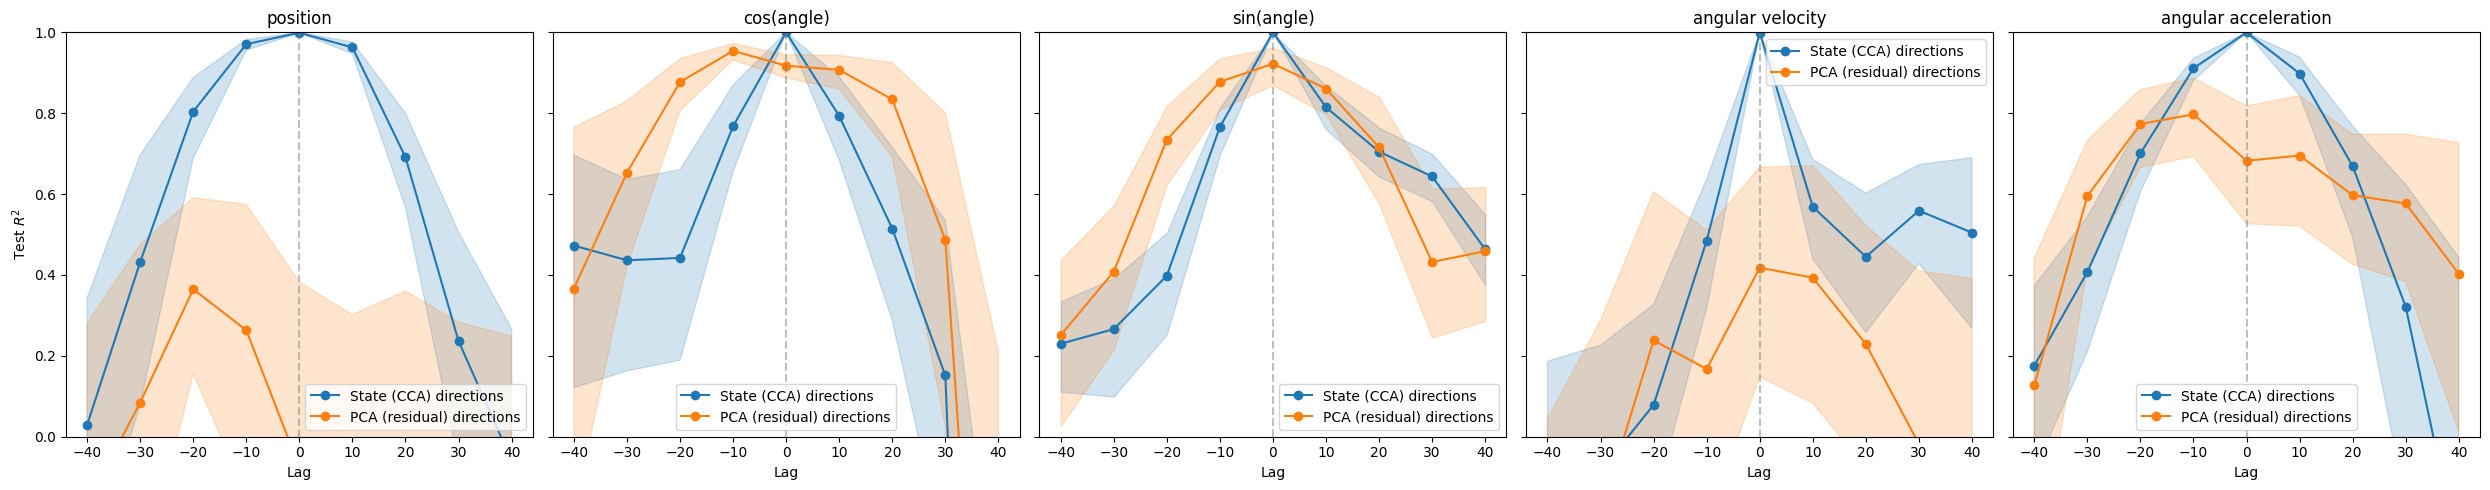

In [96]:
import matplotlib.pyplot as plt
import numpy as np

map_dim_to_name = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'angular velocity',
    4: 'angular acceleration',
}

lags = np.arange(-40, 41, 10)
fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharey=True)

for dim in range(5):
    # Means
    r2_state_dict = results_state[dim]['test_r2_mean']  # dict keyed by lag
    r2_pca_dict = results_pca[dim]['test_r2_mean']  # dict keyed by lag
    r2_state = [r2_state_dict[lag] for lag in lags]
    r2_pca = [r2_pca_dict[lag] for lag in lags]

    # CIs
    ci_state_dict = results_state[dim]['test_r2_ci']  # dict: lag -> (low, high)
    ci_pca_dict = results_pca[dim]['test_r2_ci']  # dict: lag -> (low, high)
    # Unpack into lower and upper arrays
    r2_state_ci_lower = [ci_state_dict[lag][0] for lag in lags]
    r2_state_ci_upper = [ci_state_dict[lag][1] for lag in lags]
    r2_pca_ci_lower = [ci_pca_dict[lag][0] for lag in lags]
    r2_pca_ci_upper = [ci_pca_dict[lag][1] for lag in lags]

    axes[dim].plot(lags, r2_state, marker='o', label='State (CCA) directions')
    axes[dim].fill_between(lags,
                           r2_state_ci_lower,
                           r2_state_ci_upper,
                           alpha=0.2,
                           color=axes[dim].lines[-1].get_color())

    axes[dim].plot(lags, r2_pca, marker='o', label='PCA (residual) directions')
    axes[dim].fill_between(lags,
                           r2_pca_ci_lower,
                           r2_pca_ci_upper,
                           alpha=0.2,
                           color=axes[dim].lines[-1].get_color())

    axes[dim].set_title(map_dim_to_name[dim])
    axes[dim].set_xlabel('Lag')
    if dim == 0:
        axes[dim].set_ylabel('Test $R^2$')
    axes[dim].axvline(0, color='gray', linestyle='--', alpha=0.5)
    axes[dim].legend()
    axes[dim].set_ylim(0, 1)

fig.tight_layout()
plt.show()

## Agent performance

In [15]:
# Base configuration for state-based environment

CKPT_PATH_STATE = f'logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/{CKPT_TO_USE}.pt'

override_cfg_state = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH_STATE,
    obs='state',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,
    record_planning=False,
)

# Create state-based environment
with initialize(config_path="tdmpc2", version_base=None):
    cfg_state = compose(config_name="config")
    OmegaConf.set_struct(cfg_state, False)
    cfg_state = OmegaConf.merge(cfg_state, override_cfg_state)

cfg_state = parse_cfg(cfg_state)
set_seed(cfg_state.seed)

cfg_state.initial_state = {
    'qpos': {
        'slider': 0,
        'hinge_1': 0,
    },
}

env_state = make_env(cfg_state)

print("\nLoading state-based agent...")
agent_state = ProjectedTDMPC2(cfg_state, projector)
if hasattr(cfg_state, 'checkpoint') and cfg_state.checkpoint:
    print(f"Loading checkpoint: {cfg_state.checkpoint}")
    agent_state.load(cfg_state.checkpoint)



Loading state-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt


In [16]:
# # Use normally - projection is applied after encoding
# action = agent_state.act(torch.from_numpy(obs[0, :]), t0=True, eval_mode=True)

# # For analysis: get both raw and projected latents
# z_raw, z_proj = agent_state.encode_and_project(torch.from_numpy(obs[0, :]))
# plt.plot(z_raw.T.detach().cpu().numpy())
# plt.plot(z_proj.T.detach().cpu().numpy())

In [17]:
def evaluate_agent(agent, env, num_episodes=5):
    """
    Evaluate agent on environment.
    
    Returns:
        dict with episode rewards, lengths, and success rates
    """
    ep_rewards = []
    ep_lengths = []
    ep_successes = []
    observations = []
    for ep in tqdm(range(num_episodes), desc="Evaluating"):
        observations_episode = []
        obs = env.reset(initial_state={
            'qpos': {
                'slider': 0,
                'hinge_1': np.radians(180),
            },
        })
        observations_episode.append(obs.numpy())
        done = False
        ep_reward = 0
        t = 0

        for _ in tqdm(range(500)):
            obs_tensor = torch.from_numpy(obs).float() if isinstance(
                obs, np.ndarray) else obs
            action = agent.act(obs_tensor, t0=(t == 0), eval_mode=True)
            obs, reward, done, info = env.step(action)
            ep_reward += reward
            t += 1
            observations_episode.append(obs.numpy())

        observations.append(observations_episode)
        ep_rewards.append(ep_reward)
        ep_lengths.append(t)
        ep_successes.append(info.get('success', 0))

    results = {
        'rewards': ep_rewards,
        'lengths': ep_lengths,
        'successes': ep_successes,
        'mean_reward': np.mean(ep_rewards),
        'std_reward': np.std(ep_rewards),
        'mean_length': np.mean(ep_lengths),
        'success_rate': np.mean(ep_successes),
        'observations': observations,
    }

    print(f"\nResults over {num_episodes} episodes:")
    print(
        f"  Mean reward: {results['mean_reward']:.2f} ± {results['std_reward']:.2f}"
    )
    print(f"  Mean length: {results['mean_length']:.1f}")
    print(f"  Success rate: {results['success_rate']:.2%}")

    return results


# Run evaluation
results = evaluate_agent(agent_state, env_state, num_episodes=1)

Evaluating: 100%|██████████| 1/1 [00:18<00:00, 18.65s/it]


Results over 1 episodes:
  Mean reward: 881.72 ± 0.00
  Mean length: 500.0
  Success rate: 0.00%


In [18]:
from analysis.utils import reconstruct_cartpole_dmcontrol

obs_episode = np.array(results['observations'][0])
reconstruct_cartpole_dmcontrol(obs_episode, show=True)

100%|██████████| 501/501 [00:09<00:00, 55.53it/s]
